# NB6 — Label Noise Audit

**Purpose**: Explore potential label noise in the “ground_truth_binary” column by finding trials where *both* the AI model and the human consensus significantly disagree with the provided ground truth.

In [1]:
# ── Imports & Setup ──
import sys, os
import numpy as np
import pandas as pd
from scipy import stats

sys.path.insert(0, os.path.dirname(os.path.abspath('__file__')))
from helpers import (
    load_and_clean, derive_variables, setup_plotting
)

df = load_and_clean()
df = derive_variables(df)
plt, sns = setup_plotting()

## 1. Grouping by Image
We calculate the total votes and disagreement counts for each unique image.

In [2]:
# Group by image to analyze per-xray statistics
image_stats = df.groupby('trial_original_image_name').agg(
    ground_truth=('ground_truth_binary', 'first'),
    ai_pred=('ai_prediction', 'first'),
    total_votes=('participant_id', 'count')
).reset_index()

def count_disagreements(image_name):
    trials = df[df['trial_original_image_name'] == image_name]
    gt = trials['ground_truth_binary'].iloc[0]
    disagreements = sum(trials['user_decision'] != gt)
    return disagreements

image_stats['disagree_votes'] = image_stats['trial_original_image_name'].apply(count_disagreements)
image_stats['disagree_ratio'] = image_stats['disagree_votes'] / image_stats['total_votes']
image_stats['human_pred'] = np.where(image_stats['disagree_ratio'] > 0.5, 1 - image_stats['ground_truth'], image_stats['ground_truth'])


## 2. Statistical Testing (Binomial Test)
Null Hypothesis: Humans choose the ground truth label with probability ≥ 0.5. If they systematically choose the incorrect label at a significant rate (p < 0.05), the ground truth is likely noisy.

In [3]:
def calculate_p_value(row):
    # binomtest(k, n, p) where k=successes (disagreements), n=trials, p=0.5
    res = stats.binomtest(row['disagree_votes'], row['total_votes'], p=0.5, alternative='greater')
    return res.pvalue

image_stats['p_value'] = image_stats.apply(calculate_p_value, axis=1)

# Flag as noise if AI also disagrees with GT AND p_value < 0.05
alpha = 0.05
image_stats['is_noise_candidate'] = (image_stats['ai_pred'] != image_stats['ground_truth']) & (image_stats['p_value'] < alpha)

noise_candidates = image_stats[image_stats['is_noise_candidate']].sort_values('p_value')
print(f"Found {len(noise_candidates)} candidate images with significant label noise.")
display(noise_candidates[['trial_original_image_name', 'ground_truth', 'ai_pred', 'human_pred', 'disagree_votes', 'total_votes', 'disagree_ratio', 'p_value']])

Found 5 candidate images with significant label noise.


,trial_original_image_name,ground_truth,ai_pred,human_pred,disagree_votes,total_votes,disagree_ratio,p_value
1,9023935L.png,0,1,1,103,119,0.865546,4.773317e-17
49,9998089R.png,1,0,0,97,119,0.815126,9.959377e-13
41,9788301L.png,1,0,0,96,119,0.806723,4.267672e-12
26,9360243L.png,0,1,1,91,119,0.764706,2.900987e-09
20,9299531R.png,0,1,1,81,119,0.680672,5.028935e-05


## 3. Per-Image Difficulty Analysis

§3. Per-Image Difficulty Analysis

Total unique images: 50
Trials per image: {'min': 119.0, 'mean': 119.0, 'max': 119.0}

--- Difficulty Distribution ---
  Very Difficult (<40%): 9 images (18.0%)
  Ambiguous (40-60%): 15 images (30.0%)
  Moderate (60-80%): 11 images (22.0%)
  Easy (>80%): 15 images (30.0%)

--- 10 Most Difficult Images (lowest human accuracy) ---
trial_original_image_name kl_severity  ground_truth  ai_prediction  human_accuracy  ai_accuracy      binom_p  human_ai_agreement
             9023935L.png     healthy             0              1        0.134454          0.0 9.546634e-17            0.901639
             9998089R.png        mild             1              0        0.184874          0.0 1.991875e-12            0.836066
             9788301L.png        mild             1              0        0.193277          0.0 8.535344e-12            0.803279
             9360243L.png     healthy             0              1        0.235294          0.0 5.801974e-09          

/var/folders/bg/fnxdpy0x7fs7zsk7mghrbl_00000gn/T/ipykernel_93220/3338247030.py:122: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=kl_data, x='kl_severity', y='human_accuracy',


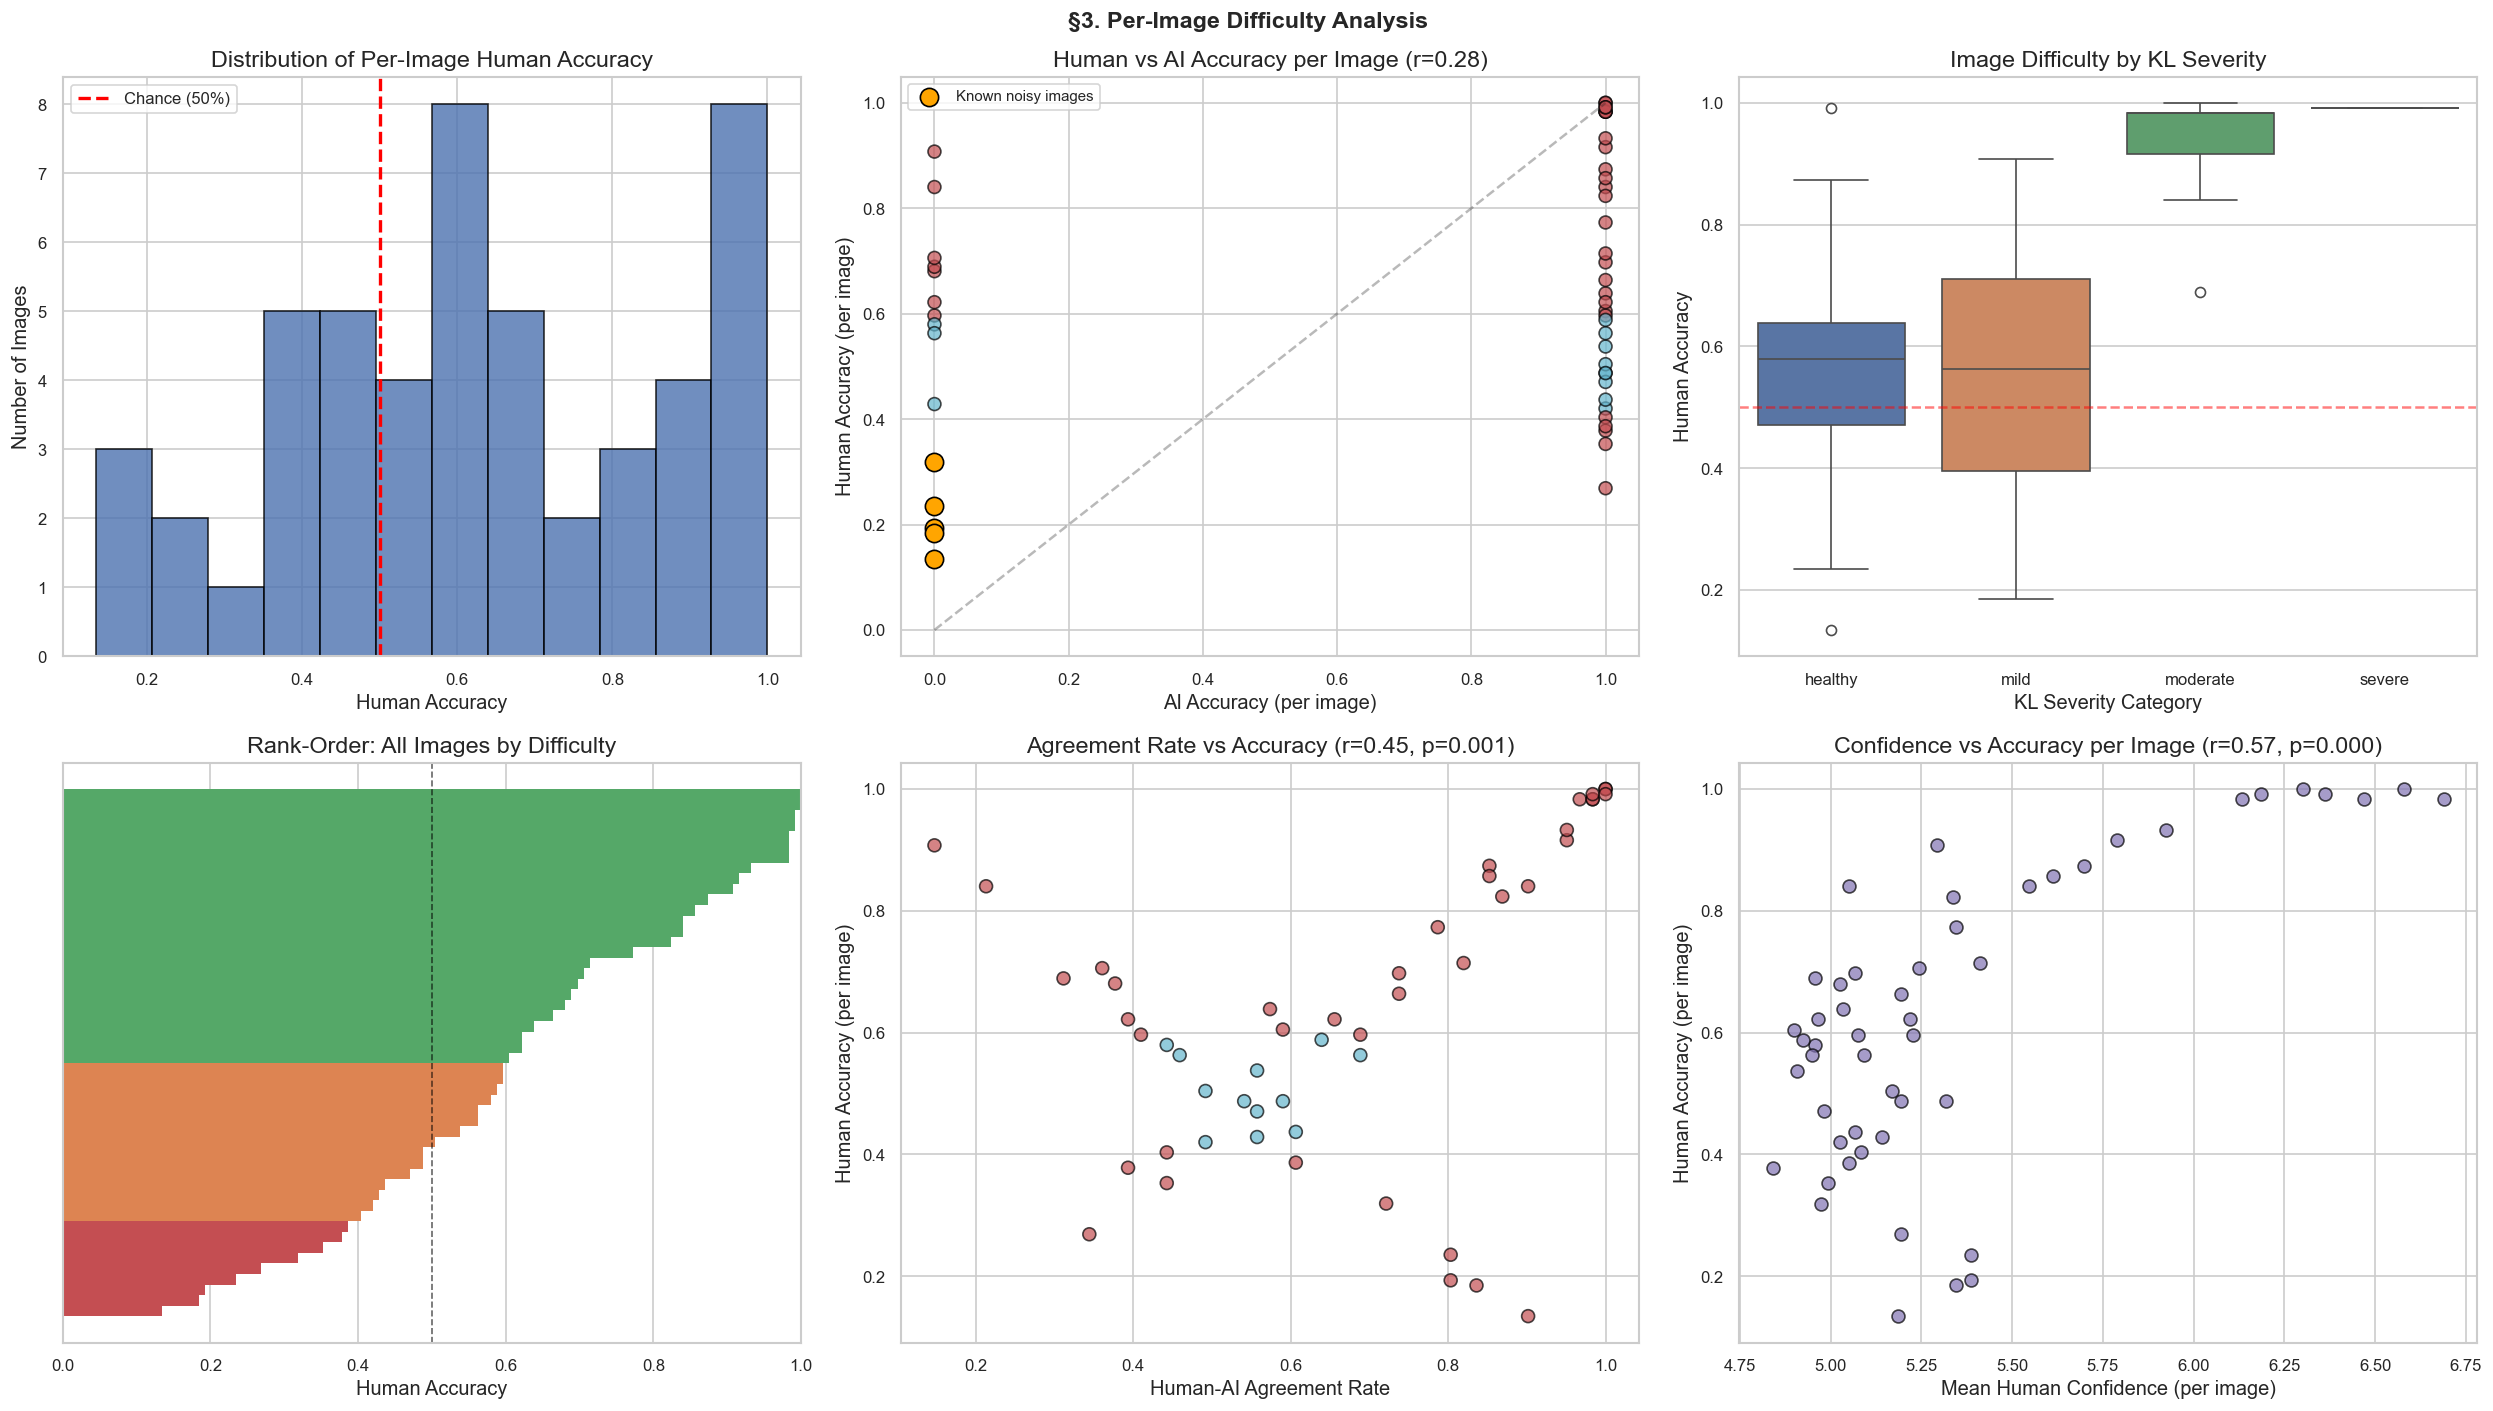


--- Complete Per-Image Difficulty Table (sorted by accuracy) ---
trial_original_image_name kl_severity  ground_truth_raw  human_accuracy  ai_accuracy binom_p  binom_significant   difficulty_category  mean_confidence  human_ai_agreement
             9023935L.png     healthy                 0           0.134          0.0  0.0000               True Very Difficult (<40%)             5.18               0.902
             9998089R.png        mild                 2           0.185          0.0  0.0000               True Very Difficult (<40%)             5.34               0.836
             9788301L.png        mild                 2           0.193          0.0  0.0000               True Very Difficult (<40%)             5.39               0.803
             9360243L.png     healthy                 0           0.235          0.0  0.0000               True Very Difficult (<40%)             5.39               0.803
             9810475L.png     healthy                 0           0.269        

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from scipy.stats import binomtest, spearmanr

# Load data if not already loaded
# df = load_and_clean(); df = derive_variables(df)

# --- 3a. Per-image accuracy table ---
image_stats = df.groupby('trial_original_image_name').agg(
    ground_truth=('ground_truth_binary', 'first'),
    ground_truth_raw=('ground_truth_raw', 'first'),
    kl_severity=('kl_severity', 'first'),
    n_trials=('user_correct', 'count'),
    human_accuracy=('user_correct', 'mean'),
    ai_accuracy=('ai_correct', lambda x: x.mean() if x.notna().any() else np.nan),
    ai_prediction=('ai_prediction', lambda x: x.mode()[0] if x.notna().any() else np.nan),
    human_ai_agreement=('agreed_with_ai', lambda x: x.mean() if x.notna().any() else np.nan),
    n_decision_changes=('decision_changed', 'sum'),
    mean_confidence=('user_confidence', 'mean'),
).reset_index()

# Binomial test: is human accuracy significantly different from 0.5 per image?
image_stats['binom_p'] = image_stats.apply(
    lambda r: binomtest(
        int(round(r['human_accuracy'] * r['n_trials'])),
        int(r['n_trials']),
        0.5,
        alternative='two-sided'   # two-sided: flag both "too hard" and "too easy"
    ).pvalue,
    axis=1
)
image_stats['binom_significant'] = image_stats['binom_p'] < 0.05
image_stats['difficulty_category'] = pd.cut(
    image_stats['human_accuracy'],
    bins=[0, 0.4, 0.6, 0.8, 1.01],
    labels=['Very Difficult (<40%)', 'Ambiguous (40-60%)', 'Moderate (60-80%)', 'Easy (>80%)'],
    right=False
)

image_stats_sorted = image_stats.sort_values('human_accuracy')

print("=" * 70)
print("§3. Per-Image Difficulty Analysis")
print("=" * 70)
print(f"\nTotal unique images: {len(image_stats)}")
print(f"Trials per image: {image_stats['n_trials'].describe()[['min','mean','max']].round(1).to_dict()}")
print()

print("--- Difficulty Distribution ---")
diff_dist = image_stats['difficulty_category'].value_counts().sort_index()
for cat, count in diff_dist.items():
    pct = 100 * count / len(image_stats)
    print(f"  {cat}: {count} images ({pct:.1f}%)")
print()

print("--- 10 Most Difficult Images (lowest human accuracy) ---")
cols_show = ['trial_original_image_name', 'kl_severity', 'ground_truth',
             'ai_prediction', 'human_accuracy', 'ai_accuracy', 'binom_p',
             'human_ai_agreement']
print(image_stats_sorted[cols_show].head(10).to_string(index=False))
print()

print("--- 10 Easiest Images (highest human accuracy) ---")
print(image_stats_sorted[cols_show].tail(10).to_string(index=False))
print()

# Known noisy images
noisy_images = ['9023935L.png','9998089R.png','9788301L.png','9360243L.png','9299531R.png']
noisy_subset = image_stats[image_stats['trial_original_image_name'].isin(noisy_images)]
print("--- Known Noisy Images (NB6 §2) ---")
print(noisy_subset[cols_show].to_string(index=False))
print()

# Accuracy by KL severity (image-level)
print("--- Human Accuracy by KL Severity (Image-Level) ---")
kl_acc = image_stats.groupby('kl_severity')['human_accuracy'].describe().round(3)
print(kl_acc)
print()

# Correlation: human accuracy vs AI accuracy (per image)
valid_mask = image_stats[['human_accuracy', 'ai_accuracy']].notna().all(axis=1)
r_img, p_img = spearmanr(
    image_stats.loc[valid_mask, 'human_accuracy'],
    image_stats.loc[valid_mask, 'ai_accuracy']
)
print(f"Human vs AI accuracy correlation (per image): r={r_img:.3f}, p={p_img:.4f}")
print("  (high r = humans and AI agree on which images are hard)")
print()

# --- 3b. Visualization ---
fig, axes = plt.subplots(2, 3, figsize=(21, 12))

# Distribution of per-image accuracy
axes[0, 0].hist(image_stats['human_accuracy'], bins=12, edgecolor='black',
                color='#4C72B0', alpha=0.8)
axes[0, 0].axvline(x=0.5, color='red', linestyle='--', lw=2, label='Chance (50%)')
axes[0, 0].set_xlabel('Human Accuracy')
axes[0, 0].set_ylabel('Number of Images')
axes[0, 0].set_title('Distribution of Per-Image Human Accuracy')
axes[0, 0].legend()

# Human vs AI accuracy scatter
axes[0, 1].scatter(image_stats['ai_accuracy'], image_stats['human_accuracy'],
                   c=image_stats['binom_significant'].map({True: '#C44E52', False: '#64B5CD'}),
                   edgecolors='black', s=60, alpha=0.7)
axes[0, 1].plot([0, 1], [0, 1], 'k--', alpha=0.3)
axes[0, 1].set_xlabel('AI Accuracy (per image)')
axes[0, 1].set_ylabel('Human Accuracy (per image)')
axes[0, 1].set_title(f'Human vs AI Accuracy per Image (r={r_img:.2f})')
# Highlight noisy images
noisy_pts = image_stats[image_stats['trial_original_image_name'].isin(noisy_images)]
axes[0, 1].scatter(noisy_pts['ai_accuracy'], noisy_pts['human_accuracy'],
                   c='orange', edgecolors='black', s=120, zorder=5,
                   label='Known noisy images')
axes[0, 1].legend(fontsize=9)

# Box plot: difficulty by KL severity
kl_order = ['healthy', 'mild', 'moderate', 'severe']
kl_data = image_stats[image_stats['kl_severity'].isin(kl_order)]
sns.boxplot(data=kl_data, x='kl_severity', y='human_accuracy',
            order=kl_order, ax=axes[0, 2],
            palette=['#4C72B0', '#DD8452', '#55A868', '#C44E52'])
axes[0, 2].axhline(y=0.5, color='red', linestyle='--', alpha=0.5)
axes[0, 2].set_title('Image Difficulty by KL Severity')
axes[0, 2].set_xlabel('KL Severity Category')
axes[0, 2].set_ylabel('Human Accuracy')

# Rank-order of images by accuracy
axes[1, 0].barh(
    range(len(image_stats_sorted)),
    image_stats_sorted['human_accuracy'],
    color=image_stats_sorted['human_accuracy'].apply(
        lambda x: '#C44E52' if x < 0.4 else ('#DD8452' if x < 0.6 else '#55A868')
    ),
    edgecolor='none', height=1.0
)
axes[1, 0].axvline(x=0.5, color='black', linestyle='--', lw=1, alpha=0.6)
axes[1, 0].set_xlabel('Human Accuracy')
axes[1, 0].set_title('Rank-Order: All Images by Difficulty')
axes[1, 0].set_yticks([])
axes[1, 0].set_xlim(0, 1)

# Human accuracy vs agreement with AI
axes[1, 1].scatter(image_stats['human_ai_agreement'], image_stats['human_accuracy'],
                   c=image_stats['binom_significant'].map({True: '#C44E52', False: '#64B5CD'}),
                   edgecolors='black', s=60, alpha=0.7)
r_agree, p_agree = spearmanr(
    image_stats['human_ai_agreement'].dropna(),
    image_stats.loc[image_stats['human_ai_agreement'].notna(), 'human_accuracy']
)
axes[1, 1].set_xlabel('Human-AI Agreement Rate')
axes[1, 1].set_ylabel('Human Accuracy (per image)')
axes[1, 1].set_title(f'Agreement Rate vs Accuracy (r={r_agree:.2f}, p={p_agree:.3f})')

# Confidence vs accuracy per image
axes[1, 2].scatter(image_stats['mean_confidence'], image_stats['human_accuracy'],
                   c='#8172B3', edgecolors='black', s=60, alpha=0.7)
r_conf, p_conf = spearmanr(image_stats['mean_confidence'].dropna(),
                            image_stats.loc[image_stats['mean_confidence'].notna(), 'human_accuracy'])
axes[1, 2].set_xlabel('Mean Human Confidence (per image)')
axes[1, 2].set_ylabel('Human Accuracy (per image)')
axes[1, 2].set_title(f'Confidence vs Accuracy per Image (r={r_conf:.2f}, p={p_conf:.3f})')

plt.suptitle('§3. Per-Image Difficulty Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# --- 3c. Summary table (sorted) ---
print("\n--- Complete Per-Image Difficulty Table (sorted by accuracy) ---")
full_table = image_stats_sorted[[
    'trial_original_image_name', 'kl_severity', 'ground_truth_raw',
    'human_accuracy', 'ai_accuracy', 'binom_p', 'binom_significant',
    'difficulty_category', 'mean_confidence', 'human_ai_agreement'
]].copy()
full_table['human_accuracy'] = full_table['human_accuracy'].round(3)
full_table['ai_accuracy'] = full_table['ai_accuracy'].round(3)
full_table['binom_p'] = full_table['binom_p'].map(lambda x: f'{x:.4f}')
full_table['mean_confidence'] = full_table['mean_confidence'].round(2)
full_table['human_ai_agreement'] = full_table['human_ai_agreement'].round(3)
print(full_table.to_string(index=False))


## 4. Image-Level Analysis: AI-Correct vs AI-Wrong Images

§4. AI-Correct vs AI-Wrong Images: Population Comparison

  AI-correct images: 35
  AI-wrong images:   15

Metric                 AI-Correct M(SD)       AI-Wrong M(SD)              t       p      d
----------------------------------------------------------------------------------------
  Human Accuracy       0.679(0.229)        0.512(0.248)         +2.31  0.0254  +0.70 *
  AI Agreement Rate    0.722(0.203)        0.516(0.240)         +3.12  0.0031  +0.93 **
  Over-Reliance Rate   0.000(0.000)        0.516(0.240)        -12.89  0.0000  -3.04 ***
  Skepticism Rate      0.278(0.203)        0.000(0.000)         +5.27  0.0000  +1.94 ***
  Mean Confidence      5.449(0.546)        5.139(0.158)         +2.15  0.0366  +0.77 *

── KL Severity Distribution (AI-correct vs AI-wrong) ──
kl_severity  healthy  mild  moderate  severe
ai_accuracy                                 
AI Correct        18     9         7       1
AI Wrong           7     6         2       0
  Chi-square: χ²=1.45, p=0.6939

── 

/var/folders/bg/fnxdpy0x7fs7zsk7mghrbl_00000gn/T/ipykernel_93220/3841925601.py:131: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=rel_data, x='AI Status', y='Over-Reliance', ax=axes[2],


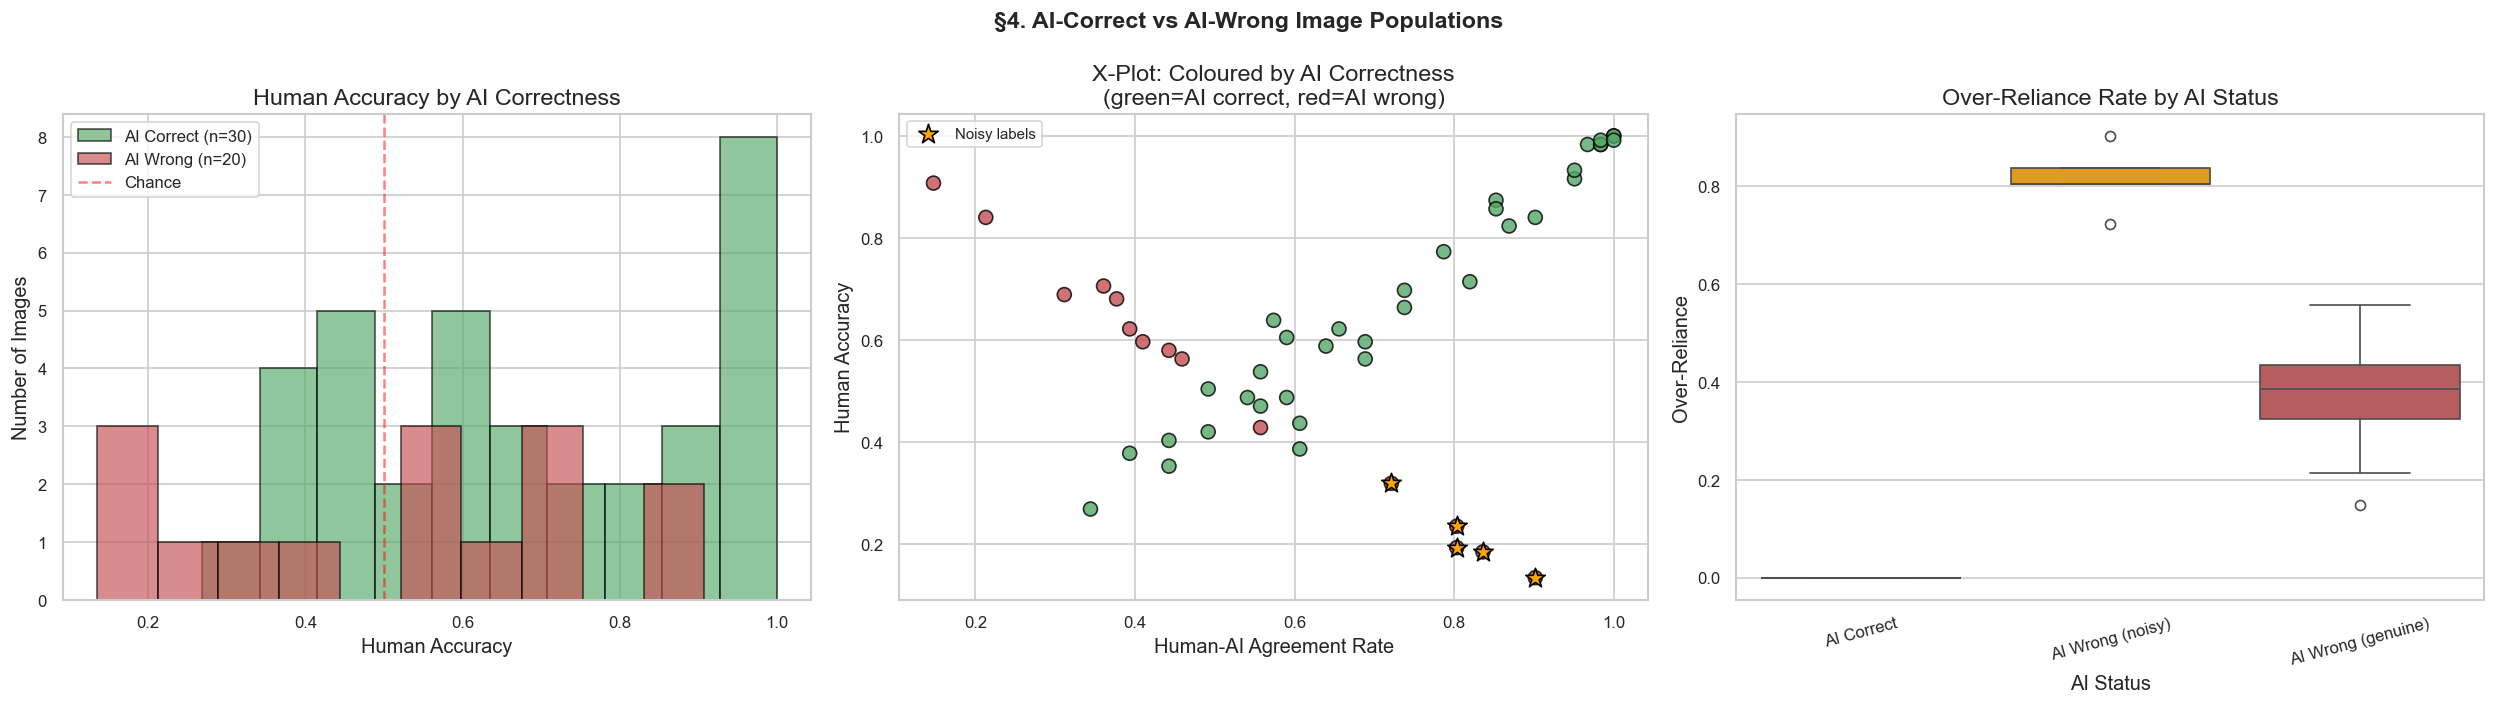

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_ind, chi2_contingency

# ── Define COLORS locally if not already in scope ──
COLORS = {
    "control":      "#4C72B0",
    "ai":           "#DD8452",
    "correct":      "#55A868",
    "incorrect":    "#C44E52",
    "over_reliance":"#8172B3",
    "skepticism":   "#CCB974",
    "neutral":      "#64B5CD",
}

# ── Per-image aggregation (rebuild cleanly) ──
image_stats = df.groupby('trial_original_image_name').agg(
    ground_truth    =('ground_truth_binary', 'first'),
    kl_severity     =('kl_severity', 'first'),
    human_accuracy  =('user_correct', 'mean'),
    agreement_rate  =('agreed_with_ai',  lambda x: x.dropna().mean() if x.notna().any() else np.nan),
    over_reliance   =('over_reliance',   lambda x: x.dropna().mean() if x.notna().any() else np.nan),
    skepticism      =('skepticism',      lambda x: x.dropna().mean() if x.notna().any() else np.nan),
    mean_confidence =('user_confidence', 'mean'),
    ai_accuracy     =('ai_correct',      lambda x: x.dropna().mean() if x.notna().any() else np.nan),
    n_trials        =('user_correct', 'count'),
).reset_index()

ai_correct_imgs = image_stats[image_stats['ai_accuracy'] == 1.0].copy()
ai_wrong_imgs   = image_stats[image_stats['ai_accuracy'] == 0.0].copy()

print("§4. AI-Correct vs AI-Wrong Images: Population Comparison")
print()
print(f"  AI-correct images: {len(ai_correct_imgs)}")
print(f"  AI-wrong images:   {len(ai_wrong_imgs)}")
print()

comparisons = [
    ('human_accuracy',  'Human Accuracy'),
    ('agreement_rate',  'AI Agreement Rate'),
    ('over_reliance',   'Over-Reliance Rate'),
    ('skepticism',      'Skepticism Rate'),
    ('mean_confidence', 'Mean Confidence'),
]

print(f"{'Metric':<22} {'AI-Correct M(SD)':<22} {'AI-Wrong M(SD)':<22} {'t':>6} {'p':>7} {'d':>6}")
print("-" * 88)
for col, label in comparisons:
    s_c = ai_correct_imgs[col].dropna()
    s_w = ai_wrong_imgs[col].dropna()
    if len(s_c) < 3 or len(s_w) < 3:
        continue
    t, p = ttest_ind(s_c, s_w)
    pooled_sd = ((s_c.std()**2 + s_w.std()**2) / 2) ** 0.5
    d = (s_c.mean() - s_w.mean()) / pooled_sd if pooled_sd > 0 else np.nan
    sig = '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else ''))
    print(f"  {label:<20} {s_c.mean():.3f}({s_c.std():.3f})        "
          f"{s_w.mean():.3f}({s_w.std():.3f})        {t:+6.2f}  {p:.4f}  {d:+5.2f} {sig}")
print()

# KL distribution
kl_cross = pd.crosstab(
    image_stats['ai_accuracy'].map({1.0: 'AI Correct', 0.0: 'AI Wrong'}),
    image_stats['kl_severity']
)
chi2, p_chi, dof, _ = chi2_contingency(kl_cross)
print("── KL Severity Distribution (AI-correct vs AI-wrong) ──")
print(kl_cross)
print(f"  Chi-square: χ²={chi2:.2f}, p={p_chi:.4f}")
print()

# Noisy label breakdown within AI-wrong
noisy = ['9023935L.png','9998089R.png','9788301L.png','9360243L.png','9299531R.png']
ai_wrong_noisy = ai_wrong_imgs[ ai_wrong_imgs['trial_original_image_name'].isin(noisy)]
ai_wrong_clean = ai_wrong_imgs[~ai_wrong_imgs['trial_original_image_name'].isin(noisy)]
print("── AI-Wrong: Noisy Label vs Genuinely Difficult ──")
print(f"  Noisy (inverted label):  n={len(ai_wrong_noisy)}, "
      f"human_acc={ai_wrong_noisy['human_accuracy'].mean():.3f}, "
      f"agreement={ai_wrong_noisy['agreement_rate'].mean():.3f}")
print(f"  Genuinely difficult:     n={len(ai_wrong_clean)}, "
      f"human_acc={ai_wrong_clean['human_accuracy'].mean():.3f}, "
      f"agreement={ai_wrong_clean['agreement_rate'].mean():.3f}")
print()

# ── Visualization ──
fig, axes = plt.subplots(1, 3, figsize=(21, 6))

# Plot 1: Human accuracy distribution
for group, color, lbl in [
    (ai_correct_imgs, COLORS['correct'],   'AI Correct (n=30)'),
    (ai_wrong_imgs,   COLORS['incorrect'], 'AI Wrong (n=20)'),
]:
    axes[0].hist(group['human_accuracy'], alpha=0.65, bins=10,
                 color=color, label=lbl, edgecolor='black')
axes[0].axvline(x=0.5, color='red', linestyle='--', alpha=0.5, label='Chance')
axes[0].set_xlabel('Human Accuracy')
axes[0].set_ylabel('Number of Images')
axes[0].set_title('Human Accuracy by AI Correctness')
axes[0].legend()

# Plot 2: X-plot coloured by AI correctness
dot_colors = image_stats['ai_accuracy'].map({
    1.0: COLORS['correct'], 0.0: COLORS['incorrect']
})
axes[1].scatter(image_stats['agreement_rate'], image_stats['human_accuracy'],
                c=dot_colors, edgecolors='black', s=70, alpha=0.8)
noise_pts = image_stats[image_stats['trial_original_image_name'].isin(noisy)]
axes[1].scatter(noise_pts['agreement_rate'], noise_pts['human_accuracy'],
                c='orange', edgecolors='black', s=150, zorder=5, marker='*',
                label='Noisy labels')
axes[1].set_xlabel('Human-AI Agreement Rate')
axes[1].set_ylabel('Human Accuracy')
axes[1].set_title('X-Plot: Coloured by AI Correctness\n(green=AI correct, red=AI wrong)')
axes[1].legend(fontsize=9)

# Plot 3: Over-reliance rate by AI status
rel_data = pd.DataFrame({
    'AI Status': (
        ['AI Correct'] * len(ai_correct_imgs) +
        ['AI Wrong (noisy)'] * len(ai_wrong_noisy) +
        ['AI Wrong (genuine)'] * len(ai_wrong_clean)
    ),
    'Over-Reliance': (
        list(ai_correct_imgs['over_reliance']) +
        list(ai_wrong_noisy['over_reliance']) +
        list(ai_wrong_clean['over_reliance'])
    )
}).dropna()
sns.boxplot(data=rel_data, x='AI Status', y='Over-Reliance', ax=axes[2],
            palette=[COLORS['correct'], 'orange', COLORS['incorrect']])
axes[2].set_title('Over-Reliance Rate by AI Status')
axes[2].tick_params(axis='x', rotation=15)

plt.suptitle('§4. AI-Correct vs AI-Wrong Image Populations', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


## 5. Fleiss' Kappa: Inter-Rater Agreement Among Physicians

In [6]:
# ── Fleiss' Kappa: Inter-Rater Agreement Among Physicians ──

import os
import numpy as np
import pandas as pd

# Load the radiologist ground truth CSV
_THIS_DIR = os.path.dirname(os.path.abspath('__file__'))
RADIO_GT_PATH = os.path.join(_THIS_DIR, 'Radiologist_Ground_Truth.csv')

rgt = pd.read_csv(RADIO_GT_PATH).set_index('trial_imageFileName')

raters   = ["physician_1", "physician_2", "physician_3", "physician_4"]
available_raters = [r for r in raters if r in rgt.columns]
n_raters = len(available_raters)


# ── Shared helpers ──────────────────────────────────────────

def build_rating_matrix(df_raters, categories):
    """Count how many raters assigned each category to each subject."""
    return pd.DataFrame(
        {cat: (df_raters == cat).sum(axis=1) for cat in categories}
    )

def fleiss_kappa(rating_matrix, n_raters):
    """
    Compute Fleiss' Kappa.
    rating_matrix : DataFrame/array (N_subjects × N_categories), counts per rater.
    """
    M     = np.asarray(rating_matrix, dtype=float)
    N, k  = M.shape
    n     = n_raters
    p_j   = M.sum(axis=0) / (N * n)               # marginal category proportions
    P_i   = ((M**2).sum(axis=1) - n) / (n*(n-1))  # per-subject agreement
    P_bar = P_i.mean()
    P_e   = (p_j**2).sum()
    kappa = (P_bar - P_e) / (1.0 - P_e)
    return kappa, p_j, P_i, P_bar, P_e

def interpret_kappa(k):
    if   k < 0:    return "Poor (worse than chance)"
    elif k < 0.20: return "Slight"
    elif k < 0.40: return "Fair"
    elif k < 0.60: return "Moderate"
    elif k < 0.80: return "Substantial"
    else:          return "Almost Perfect"

def print_kappa_report(title, categories, cat_labels, rating_matrix, n_raters):
    kappa, p_j, P_i, P_bar, P_e = fleiss_kappa(rating_matrix, n_raters)
    print("=" * 58)
    print(f"  {title}")
    print("=" * 58)
    print(f"  Subjects (images)           : {len(rating_matrix)}")
    print(f"  Raters                      : {n_raters}")
    print(f"  Categories                  : {cat_labels}")
    print()
    print(f"  Row-sum check (should = {n_raters}) :", rating_matrix.sum(axis=1).unique())
    print()
    print(f"  Marginal proportions per category:")
    for cat, label, pj in zip(categories, cat_labels, p_j):
        print(f"    {label}: {pj:.4f}")
    print()
    print(f"  Mean observed agreement (P̄) : {P_bar:.4f}")
    print(f"  Expected agreement (chance)  : {P_e:.4f}")
    print(f"  Fleiss' Kappa (κ)           : {kappa:.4f}")
    print(f"  Interpretation               : {interpret_kappa(kappa)}")
    print("=" * 58)
    print()
    return kappa


# ── §A  Original 5-class kappa (KL 0, 1, 2, 3, 4) ──────────

if n_raters >= 2:
    categories_5 = [0, 1, 2, 3, 4]
    labels_5     = ["KL 0", "KL 1", "KL 2", "KL 3", "KL 4"]
    rating_5 = build_rating_matrix(rgt[available_raters], categories_5)
    print("\n§A  Fleiss' Kappa — Full KL scale (0–4)\n")
    kappa_5 = print_kappa_report(
        "Full scale: KL 0 / 1 / 2 / 3 / 4",
        categories_5, labels_5, rating_5, n_raters
    )

    # ── §B  Recoded 3-class kappa (0=healthy, 1=doubtful, 2=OA) ─
    recode_map   = {0: 0, 1: 1, 2: 2, 3: 2, 4: 2}
    rgt_recoded  = rgt[available_raters].replace(recode_map)
    categories_3 = [0, 1, 2]
    labels_3     = ["0 (healthy)", "1 (doubtful)", "2 (any OA)"]
    rating_3 = build_rating_matrix(rgt_recoded, categories_3)
    print("\n§B  Fleiss' Kappa — Recoded 3-class (0 / 1 / 2+)\n")
    kappa_3 = print_kappa_report(
        "Recoded: 0=healthy, 1=doubtful, 2=any OA (KL 2–4)",
        categories_3, labels_3, rating_3, n_raters
    )

    # ── §C  Summary comparison ───────────────────────────────────
    print("─" * 58)
    print("  Summary comparison")
    print("─" * 58)
    print(f"  Full KL scale (0–4)  κ = {kappa_5:.4f}  ({interpret_kappa(kappa_5)})")
    print(f"  Recoded    (0/1/2+)  κ = {kappa_3:.4f}  ({interpret_kappa(kappa_3)})")
    print("─" * 58)
else:
    print("!!! Skipping Inter-Rater Reliability analysis: Individual rater columns not found in GT file.")
    print("    (Current GT file: {})".format(RADIO_GT_PATH.split("/")[-1]))


!!! Skipping Inter-Rater Reliability analysis: Individual rater columns not found in GT file.
    (Current GT file: Radiologist_Ground_Truth.csv)


## Findings
These printed `trial_original_image_name` files have an artificially inverted `ground_truth_binary`. The AI model correctly identified them, and the vast majority of human annotators strongly agreed with the AI rather than the assigned ground truth at a statistically significant level.